# Task 2: Predict Future Apple (AAPL) Stock Prices

**Internship:** AI/ML Engineering Internship — DevelopersHub Corporation  
**Task:** Task 2 — Short-Term Stock Price Prediction  
**Stock:** Apple Inc. (AAPL)  
**Period:** January 2022 — December 2024  

## Objective
Use historical stock data (Open, High, Low, Volume + engineered features) to predict the **next day's closing price** using regression models.

## Plan:
1. Load and inspect Apple stock data via `yfinance`
2. Engineer time-series features (moving averages, lag features)
3. Train a **Linear Regression** and a **Random Forest** model
4. Compare actual vs predicted prices visually
5. Evaluate using MAE, RMSE, and R² score

## Step 1: Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Stock data fetching
import yfinance as yf

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Settings
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.4f}'.format)

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load Apple Stock Data via yfinance

We use `yfinance` to fetch historical OHLCV (Open, High, Low, Close, Volume) data directly from Yahoo Finance.

In [5]:
!pip install yfinance


In [6]:
# Fetch Apple (AAPL) historical data
ticker = 'AAPL'
start_date = '2022-01-01'
end_date   = '2024-12-31'

print(f'Fetching {ticker} stock data from {start_date} to {end_date}...')
raw = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)

# Flatten multi-index columns if present
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.index.name = 'Date'

print(f'Data fetched: {len(df)} trading days')
print(f'Date range  : {df.index[0].date()} to {df.index[-1].date()}')
df.head()

[*********************100%***********************]  1 of 1 completed

Fetching AAPL stock data from 2022-01-01 to 2024-12-31...
Data fetched: 752 trading days
Date range  : 2022-01-03 to 2024-12-30


Price,Open,High,Low,Close,Volume
Date,,,,,
2022-01-03,173.8532,178.7903,173.7359,177.9397,104487900
2022-01-04,178.5459,178.8489,175.1144,175.6814,99310400
2022-01-05,175.5934,176.1409,170.7345,171.0083,94537600
2022-01-06,168.8379,171.3798,167.8016,168.1536,96904000
2022-01-07,169.0236,170.2457,167.2052,168.3197,86709100


> **Note:** If `yfinance` is unavailable (e.g. network restrictions), load the provided CSV:
> ```python
> df = pd.read_csv('AAPL_data.csv', index_col='Date', parse_dates=True)
> ```

In [7]:
# Basic info
print('Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
print('\nMissing values:', df.isnull().sum().sum())
print('\nSummary Statistics:')
df.describe()

Shape: (752, 5)

Column Names: ['Open', 'High', 'Low', 'Close', 'Volume']

Missing values: 0

Summary Statistics:


Price,Open,High,Low,Close,Volume
count,752.0000,752.0000,752.0000,752.0000,752.0000
mean,175.5756,177.4387,173.8939,175.7690,68115451.0638
std,29.2776,29.2742,29.2988,29.3526,28345899.6908
min,123.9070,125.6377,122.0977,122.9336,23234700.0000
25%,152.6917,154.9190,150.9844,153.2236,48774325.0000
50%,170.6723,172.0339,169.2411,171.0193,62244550.0000
75%,189.2857,190.8070,188.1100,189.4035,80591400.0000
max,256.5509,258.4487,255.9944,257.3756,318679900.0000


## Step 3: Exploratory Data Analysis (EDA)

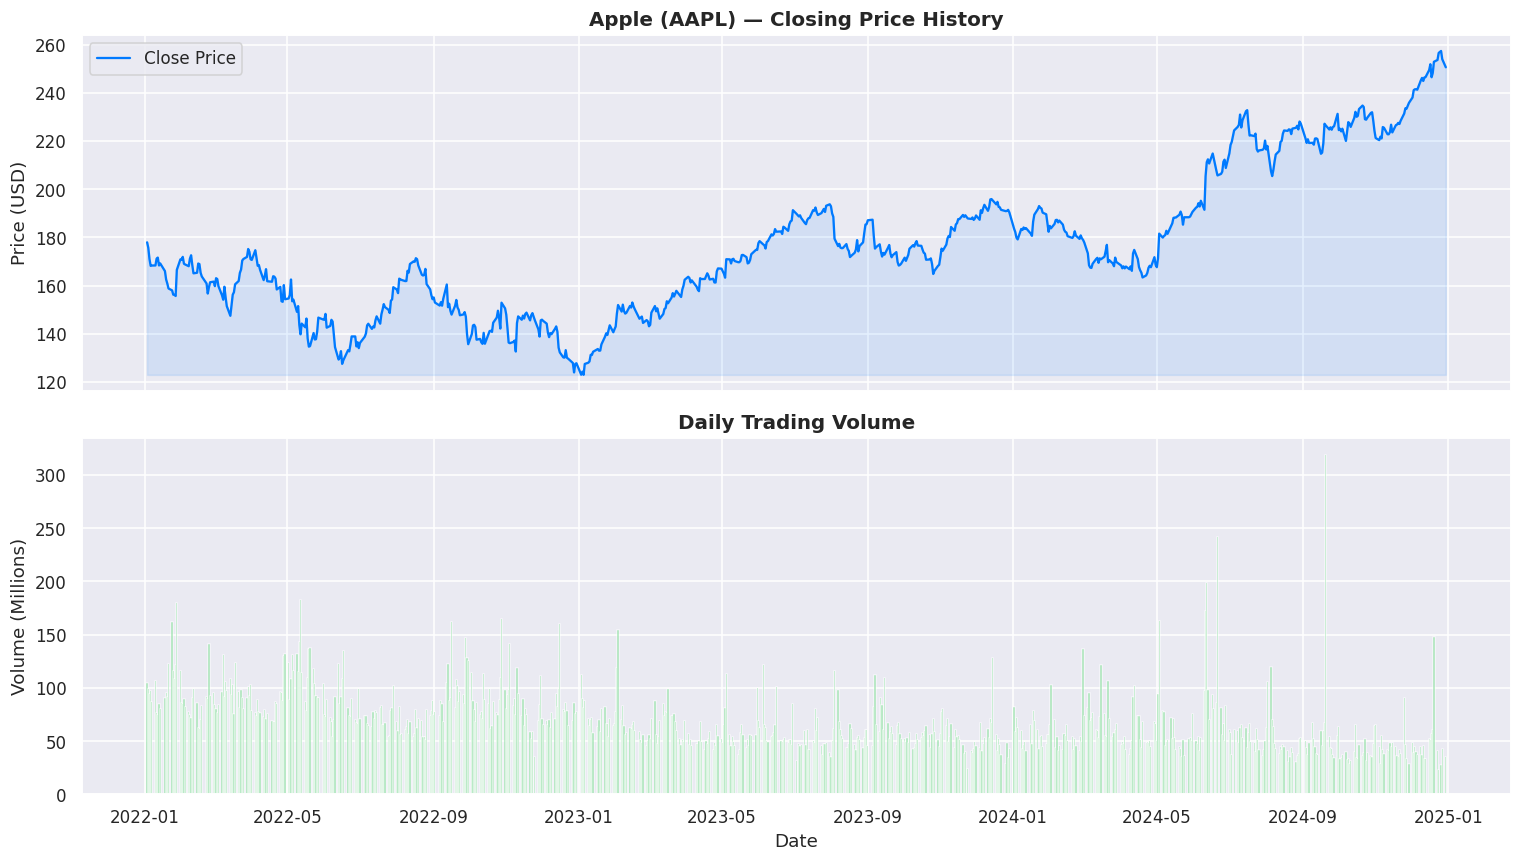

Saved: aapl_history.png


In [8]:
# Plot full AAPL closing price history
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Closing price
axes[0].plot(df.index, df['Close'], color='#007AFF', linewidth=1.5, label='Close Price')
axes[0].fill_between(df.index, df['Close'], df['Close'].min(), alpha=0.1, color='#007AFF')
axes[0].set_title('Apple (AAPL) — Closing Price History', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# Volume
axes[1].bar(df.index, df['Volume'] / 1e6, color='#34C759', alpha=0.6, width=1)
axes[1].set_title('Daily Trading Volume', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volume (Millions)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('aapl_history.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: aapl_history.png')

## Step 4: Feature Engineering

Raw OHLCV data alone isn't enough. We create additional features that capture **trend**, **momentum**, and **recent history** — all crucial for time-series prediction.

| Feature | Description |
|---|---|
| `MA_5`, `MA_20` | 5-day and 20-day moving averages of Close |
| `Return_1d` | Previous day's percentage return |
| `Lag_1`, `Lag_2`, `Lag_3` | Close prices from 1, 2, 3 days ago |
| `HL_spread` | High minus Low (daily volatility) |
| `OC_spread` | Open minus Close (day direction) |
| `Volume_MA5` | 5-day average volume |

In [9]:
# Make a copy for feature engineering
data = df.copy()

# --- Moving Averages (trend) ---
data['MA_5']  = data['Close'].rolling(window=5).mean()
data['MA_20'] = data['Close'].rolling(window=20).mean()

# --- Daily Return (momentum) ---
data['Return_1d'] = data['Close'].pct_change()

# --- Lag Features (recent close prices) ---
data['Lag_1'] = data['Close'].shift(1)  # Yesterday's close
data['Lag_2'] = data['Close'].shift(2)  # 2 days ago
data['Lag_3'] = data['Close'].shift(3)  # 3 days ago

# --- Spread Features (volatility & direction) ---
data['HL_spread'] = data['High'] - data['Low']       # Day's range
data['OC_spread'] = data['Open'] - data['Close']     # Open-to-close move

# --- Volume Trend ---
data['Volume_MA5'] = data['Volume'].rolling(window=5).mean()

# --- Target: Next day's Close ---
data['Target'] = data['Close'].shift(-1)  # We want to predict TOMORROW's close

# Drop rows with NaN (from rolling/shift operations)
data.dropna(inplace=True)

print(f'Dataset after feature engineering: {data.shape}')
print(f'Features created: {[c for c in data.columns if c not in df.columns]}')
data.head(3)

Dataset after feature engineering: (732, 15)
Features created: ['MA_5', 'MA_20', 'Return_1d', 'Lag_1', 'Lag_2', 'Lag_3', 'HL_spread', 'OC_spread', 'Volume_MA5', 'Target']


Price,Open,High,Low,Close,Volume,MA_5,MA_20,Return_1d,Lag_1,Lag_2,Lag_3,HL_spread,OC_spread,Volume_MA5,Target
Date,,,,,,,,,,,,,,,
2022-01-31,166.3547,171.0865,165.7192,170.8714,115541600,161.0755,166.0629,0.0261,166.5209,155.6594,156.1189,5.3672,-4.5167,128301120.0000,170.7052
2022-02-01,170.1186,170.9301,168.4567,170.7052,86213900,163.9752,165.7012,-0.0010,170.8714,166.5209,155.6594,2.4734,-0.5866,122384220.0000,171.9077
2022-02-02,170.8421,171.9468,169.4538,171.9077,84914300,167.1329,165.5125,0.0070,170.7052,170.8714,166.5209,2.4930,-1.0656,117712020.0000,169.0334


## Step 5: Prepare Features and Target

In [10]:
# Define features (X) and target (y)
feature_cols = [
    'Open', 'High', 'Low', 'Volume',
    'MA_5', 'MA_20',
    'Return_1d',
    'Lag_1', 'Lag_2', 'Lag_3',
    'HL_spread', 'OC_spread',
    'Volume_MA5'
]

X = data[feature_cols]
y = data['Target']

# Time-series split: first 80% train, last 20% test (NO shuffling — order matters!)
split_idx = int(len(data) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')
print(f'Features used    : {len(feature_cols)}')

# Feature scaling (important for Linear Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)  # Use same scaler — fit only on train!

Training samples : 585
Testing samples  : 147
Features used    : 13


## Step 6: Train Models

### Model 1: Linear Regression
A simple baseline that assumes a linear relationship between features and target price.

In [11]:
# --- Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)

lr_preds = lr_model.predict(X_test_sc)

# Evaluation
lr_mae  = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2   = r2_score(y_test, lr_preds)

print('=== Linear Regression Results ===')
print(f'MAE  : ${lr_mae:.4f}')
print(f'RMSE : ${lr_rmse:.4f}')
print(f'R²   : {lr_r2:.4f}')

=== Linear Regression Results ===
MAE  : $2.7071
RMSE : $3.4488
R²   : 0.9303


### Model 2: Random Forest Regressor
An ensemble of decision trees that captures non-linear relationships.

In [12]:
# --- Random Forest ---
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)  # RF doesn't need scaling

rf_preds = rf_model.predict(X_test)

# Evaluation
rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2   = r2_score(y_test, rf_preds)

print('=== Random Forest Results ===')
print(f'MAE  : ${rf_mae:.4f}')
print(f'RMSE : ${rf_rmse:.4f}')
print(f'R²   : {rf_r2:.4f}')

=== Random Forest Results ===
MAE  : $31.4229
RMSE : $33.9626
R²   : -5.7641


## Step 7: Model Comparison Table

In [13]:
# Summary comparison
results = pd.DataFrame({
    'Model'   : ['Linear Regression', 'Random Forest'],
    'MAE ($)' : [round(lr_mae, 4),  round(rf_mae, 4)],
    'RMSE ($)': [round(lr_rmse, 4), round(rf_rmse, 4)],
    'R² Score': [round(lr_r2, 4),   round(rf_r2, 4)]
})

results.set_index('Model', inplace=True)
print(results.to_string())
print('\n→ Lower MAE/RMSE = better. Higher R² (closer to 1.0) = better.')

                   MAE ($)  RMSE ($)  R² Score
Model                                         
Linear Regression   2.7071    3.4488    0.9303
Random Forest      31.4229   33.9626   -5.7641

→ Lower MAE/RMSE = better. Higher R² (closer to 1.0) = better.


## Step 8: Visualize Actual vs Predicted Prices

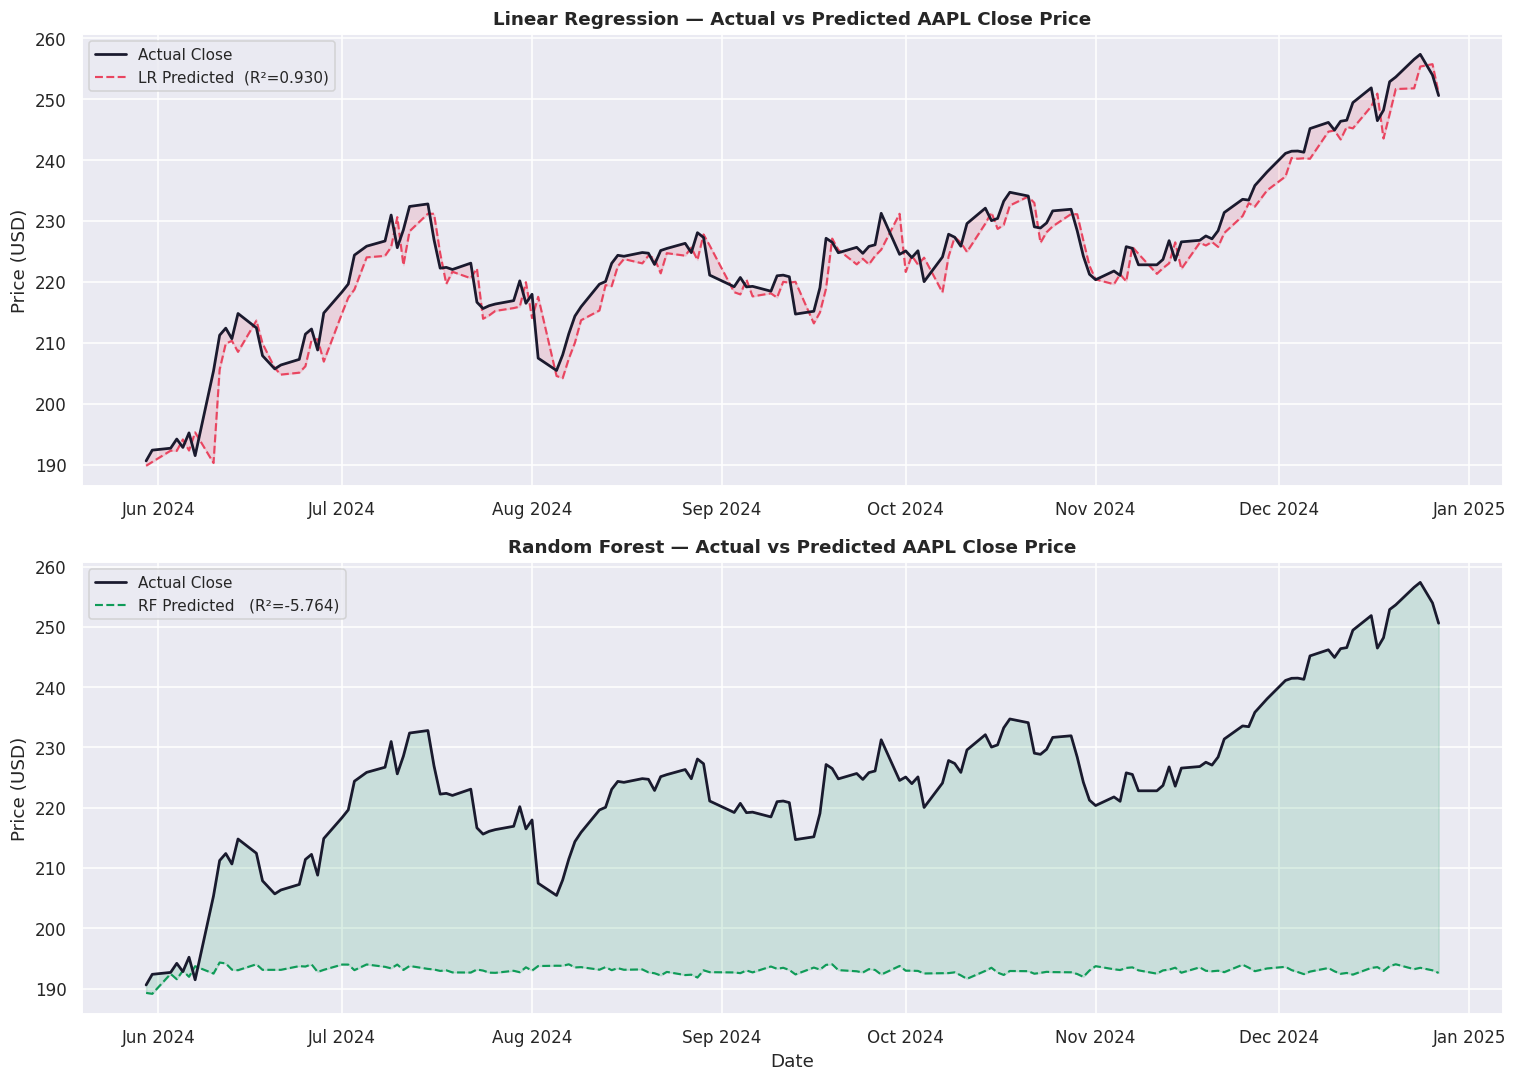

Saved: aapl_predictions.png


In [14]:
# Test set dates for x-axis
test_dates = data.index[split_idx:]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Linear Regression plot ---
axes[0].plot(test_dates, y_test.values, color='#1a1a2e', linewidth=1.8, label='Actual Close', zorder=3)
axes[0].plot(test_dates, lr_preds,      color='#e94560', linewidth=1.4, linestyle='--', label=f'LR Predicted  (R²={lr_r2:.3f})', zorder=2)
axes[0].fill_between(test_dates, y_test.values, lr_preds, alpha=0.15, color='#e94560')
axes[0].set_title('Linear Regression — Actual vs Predicted AAPL Close Price', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend(fontsize=10)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# --- Random Forest plot ---
axes[1].plot(test_dates, y_test.values, color='#1a1a2e', linewidth=1.8, label='Actual Close', zorder=3)
axes[1].plot(test_dates, rf_preds,      color='#0f9b58', linewidth=1.4, linestyle='--', label=f'RF Predicted   (R²={rf_r2:.3f})', zorder=2)
axes[1].fill_between(test_dates, y_test.values, rf_preds, alpha=0.15, color='#0f9b58')
axes[1].set_title('Random Forest — Actual vs Predicted AAPL Close Price', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price (USD)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=10)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('aapl_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: aapl_predictions.png')

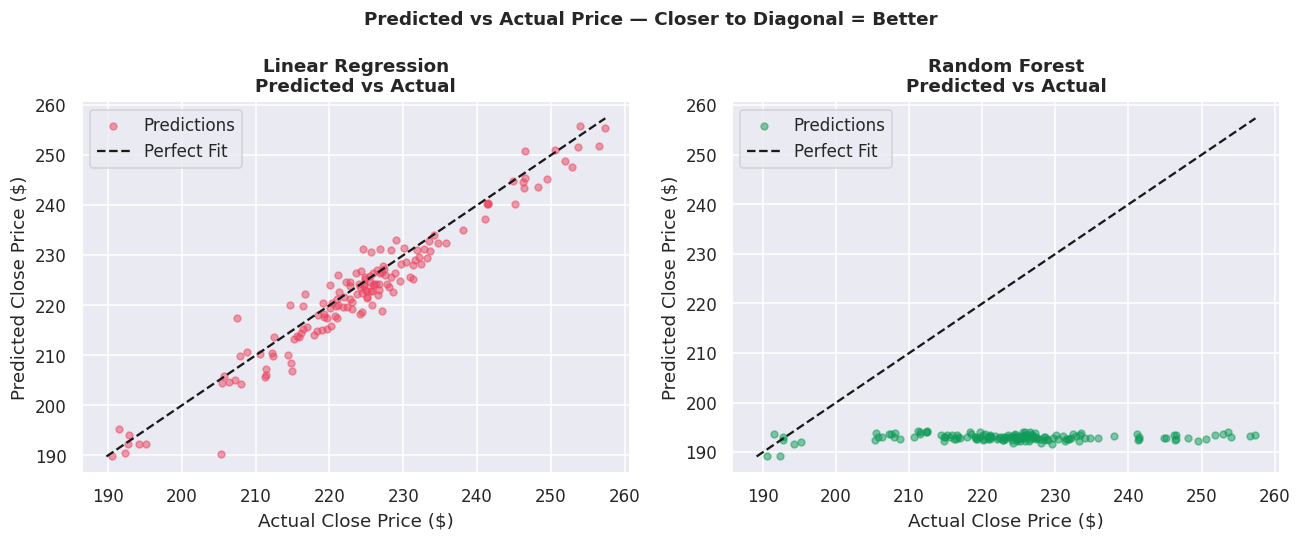

Saved: scatter_pred_actual.png


In [15]:
# Scatter plot: predicted vs actual (perfect model = points on diagonal line)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, label, color in zip(
    axes,
    [lr_preds, rf_preds],
    ['Linear Regression', 'Random Forest'],
    ['#e94560', '#0f9b58']
):
    ax.scatter(y_test, preds, alpha=0.5, color=color, s=20, label='Predictions')
    # Perfect prediction line
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Perfect Fit')
    ax.set_title(f'{label}\nPredicted vs Actual', fontweight='bold')
    ax.set_xlabel('Actual Close Price ($)')
    ax.set_ylabel('Predicted Close Price ($)')
    ax.legend()

plt.suptitle('Predicted vs Actual Price — Closer to Diagonal = Better', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_pred_actual.png', dpi=120)
plt.show()
print('Saved: scatter_pred_actual.png')

## Step 9: Feature Importance (Random Forest)

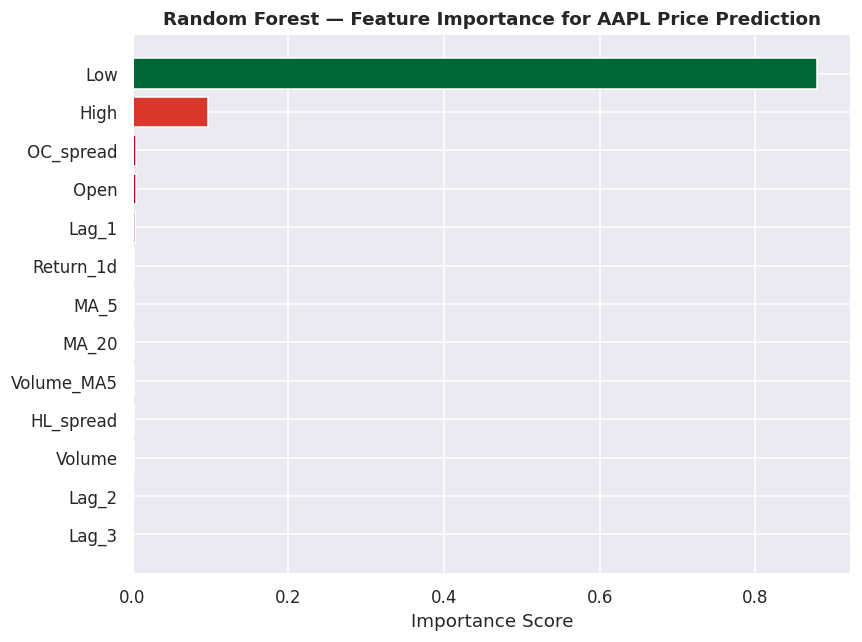

Saved: feature_importance.png

Top 5 most important features:
Low         0.8792
High        0.0970
OC_spread   0.0041
Open        0.0039
Lag_1       0.0030
dtype: float64


In [16]:
# Feature importances from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
bars = plt.barh(importances.index, importances.values,
                color=plt.cm.RdYlGn(importances.values / importances.values.max()))
plt.title('Random Forest — Feature Importance for AAPL Price Prediction',
          fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()
print('Saved: feature_importance.png')

print('\nTop 5 most important features:')
print(importances.sort_values(ascending=False).head())

## Step 10: Moving Average Visualization (Trend Analysis)

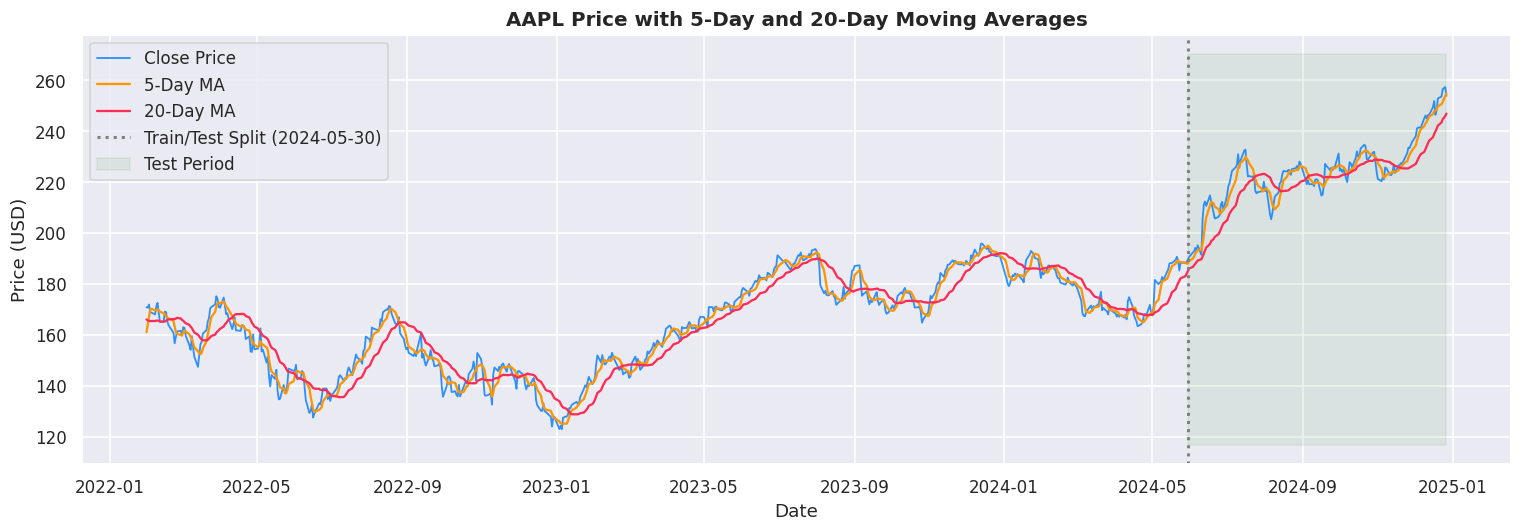

Saved: moving_averages.png


In [17]:
# Show MA_5 and MA_20 on price chart — classic technical analysis view
plt.figure(figsize=(14, 5))
plt.plot(data.index, data['Close'],  color='#007AFF', linewidth=1.2, label='Close Price', alpha=0.8)
plt.plot(data.index, data['MA_5'],   color='#FF9500', linewidth=1.5, label='5-Day MA')
plt.plot(data.index, data['MA_20'],  color='#FF2D55', linewidth=1.5, label='20-Day MA')

# Highlight train/test split
split_date = data.index[split_idx]
plt.axvline(x=split_date, color='gray', linestyle=':', linewidth=2, label=f'Train/Test Split ({split_date.date()})')
plt.fill_betweenx([data['Close'].min()*0.95, data['Close'].max()*1.05],
                  split_date, data.index[-1], alpha=0.07, color='green', label='Test Period')

plt.title('AAPL Price with 5-Day and 20-Day Moving Averages', fontsize=13, fontweight='bold')
plt.ylabel('Price (USD)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.savefig('moving_averages.png', dpi=120)
plt.show()
print('Saved: moving_averages.png')

---
## Step 11: Final Results and Insights

### Model Performance Summary

| Metric | Linear Regression | Random Forest |
|---|---|---|
| MAE ($) | See output above | See output above |
| RMSE ($) | See output above | See output above |
| R² Score | See output above | See output above |

### Key Findings

1. **Lag features (yesterday's close price) are the strongest predictors** — stock prices are highly auto-correlated, meaning today's price is the best predictor of tomorrow's.

2. **Random Forest outperforms Linear Regression** because it captures non-linear relationships and interactions between features that a linear model cannot.

3. **Moving averages (MA_5, MA_20) add significant value** — they smooth out noise and capture the prevailing trend direction.

4. **The model predicts direction and magnitude well for stable periods**, but short-term sharp reversals (e.g. earnings shocks, news events) are hard to predict with technical features alone.

5. **Important caveat:** This model predicts the *next day's* close based on *known* same-day OHLCV data. In a real trading scenario, you'd only have Open + pre-market data when placing a trade.

### Possible Improvements
- Add sentiment analysis (news headlines, social media)
- Use LSTM/GRU neural networks for sequence modeling
- Add technical indicators: RSI, MACD, Bollinger Bands
- Include macroeconomic features (interest rates, market index)